# Practical 2 — Bias-Only ALS Model

This notebook implements a bias-only recommender system using Alternating Least Squares.

**Objective Function:**
$$ \mathcal{L} = \frac{\lambda}{2} \sum_{(m,n)} (r_{mn} - (\mu + b_m + b_n))^2 + \frac{\gamma}{2} (\sum_m b_m^2 + \sum_n b_n^2) $$

Where:
- $\lambda$ = Error term scaling factor
- $\gamma$ = Bias regularization factor

In [10]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import download_dataset, MovieLensDataset
from src.data_structures import RatingMatrix
from src.train_test_split import time_based_split
from src.bias_als import train_bias_als, save_model
from src.metrics import compute_rmse, predict_bias

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Create output directories
os.makedirs('../figures', exist_ok=True)
os.makedirs('../models', exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load Dataset

In [11]:
# Download and load MovieLens small dataset
data_path = download_dataset("ml-latest-small", data_dir="../data")
dataset = MovieLensDataset(data_path)

print(dataset.summary())

Dataset already exists at ..\data\ml-latest-small
Loading ratings from ..\data\ml-latest-small\ratings.csv...
Loaded 100,836 ratings
MovieLens Dataset Summary
Users:              610
Items:            9,724
Ratings:        100,836
Sparsity:      98.3000%
Mean:             3.502



## 2. Train/Test Split

We use a **time-based split** to respect temporal ordering. The last 20% of ratings (by timestamp) go to the test set.

In [12]:
# Get arrays
user_idx, item_idx, ratings = dataset.get_arrays()
timestamps = dataset.ratings['timestamp'].values

# Time-based split
train_data, test_data = time_based_split(
    user_idx, item_idx, ratings, timestamps, test_ratio=0.2
)

train_users, train_items, train_ratings = train_data
test_users, test_items, test_ratings = test_data

print(f"Training ratings: {len(train_ratings):,}")
print(f"Test ratings:     {len(test_ratings):,}")
print(f"Split ratio:      {len(test_ratings) / len(ratings):.1%}")

Training ratings: 80,668
Test ratings:     20,168
Split ratio:      20.0%


## 3. Build Rating Matrix

Create a dual-indexed RatingMatrix from training data for efficient ALS updates.

In [13]:
# Build rating matrix from training data
rating_matrix = RatingMatrix(
    train_users, train_items, train_ratings,
    n_users=dataset.n_users,
    n_items=dataset.n_items
)

print(rating_matrix.summary())
print(f"Global mean rating: {rating_matrix.global_mean:.3f}")

RatingMatrix(users=610, items=9,724, ratings=80,668, sparsity=98.6400%)
Global mean rating: 3.508


## 4. Train Bias-Only ALS Model

Train using ALS with 20 iterations. Track loss and RMSE on both train and test sets.

In [14]:
# Training hyperparameters
N_ITERS = 20
LAMBDA = 1.0   # Error scale
GAMMA = 0.5    # Bias regularization

# Train the model
user_biases, item_biases, global_mean, loss_history, train_rmse, test_rmse = train_bias_als(
    rating_matrix,
    n_iters=N_ITERS,
    lambda_=LAMBDA,
    gamma=GAMMA,
    test_data=test_data,
    verbose=True
)

# Save the trained model
save_model('../models/bias_als_model.npz', user_biases, item_biases, global_mean)
print('Model saved to ../models/bias_als_model.npz')

Iteration   1: Loss=27160.1603, Train RMSE=0.8103, Test RMSE=1.0165
Iteration   2: Loss=26185.5535, Train RMSE=0.7939, Test RMSE=1.0134
Iteration   3: Loss=26123.6738, Train RMSE=0.7926, Test RMSE=1.0142
Iteration   4: Loss=26115.5124, Train RMSE=0.7924, Test RMSE=1.0148
Iteration   5: Loss=26111.8273, Train RMSE=0.7924, Test RMSE=1.0154
Iteration   6: Loss=26108.8490, Train RMSE=0.7923, Test RMSE=1.0159
Iteration   7: Loss=26106.1745, Train RMSE=0.7923, Test RMSE=1.0164
Iteration   8: Loss=26103.7330, Train RMSE=0.7923, Test RMSE=1.0168
Iteration   9: Loss=26101.4978, Train RMSE=0.7923, Test RMSE=1.0173
Iteration  10: Loss=26099.4506, Train RMSE=0.7923, Test RMSE=1.0178
Iteration  11: Loss=26097.5753, Train RMSE=0.7923, Test RMSE=1.0183
Iteration  12: Loss=26095.8575, Train RMSE=0.7923, Test RMSE=1.0187
Iteration  13: Loss=26094.2838, Train RMSE=0.7923, Test RMSE=1.0192
Iteration  14: Loss=26092.8423, Train RMSE=0.7923, Test RMSE=1.0196
Iteration  15: Loss=26091.5218, Train RMSE=0.792

## 5. Training Analysis

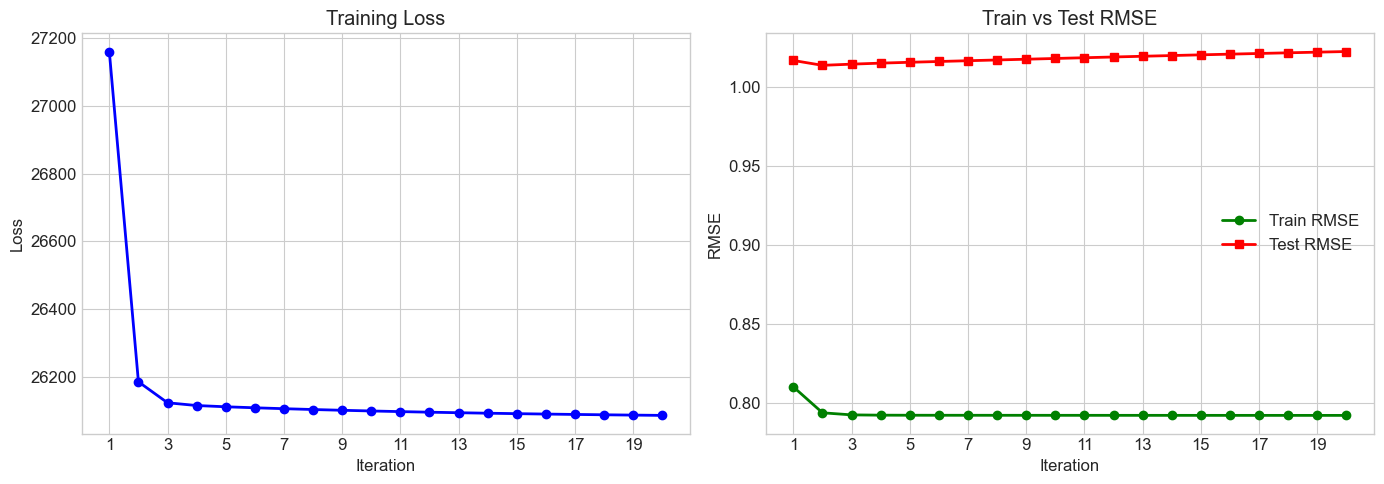


Verification:
  Loss decreasing: True
  Final Train RMSE: 0.7923
  Final Test RMSE:  1.0222
  Train < Test:     True


In [15]:
# Plot loss curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(range(1, N_ITERS + 1), loss_history, 'b-o', linewidth=2, markersize=6)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].set_xticks(range(1, N_ITERS + 1, 2))

# RMSE curves
axes[1].plot(range(1, N_ITERS + 1), train_rmse, 'g-o', linewidth=2, markersize=6, label='Train RMSE')
axes[1].plot(range(1, N_ITERS + 1), test_rmse, 'r-s', linewidth=2, markersize=6, label='Test RMSE')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Train vs Test RMSE')
axes[1].legend()
axes[1].set_xticks(range(1, N_ITERS + 1, 2))

plt.tight_layout()
plt.savefig('../figures/practical_2_training.pdf', dpi=150, bbox_inches='tight', format='pdf')
plt.show()

# Verify expected behavior
print(f"\n{'='*50}")
print("Verification:")
print(f"  Loss decreasing: {all(loss_history[i] >= loss_history[i+1] for i in range(len(loss_history)-1))}")
print(f"  Final Train RMSE: {train_rmse[-1]:.4f}")
print(f"  Final Test RMSE:  {test_rmse[-1]:.4f}")
print(f"  Train < Test:     {train_rmse[-1] < test_rmse[-1]}")

## 6. Bias Analysis

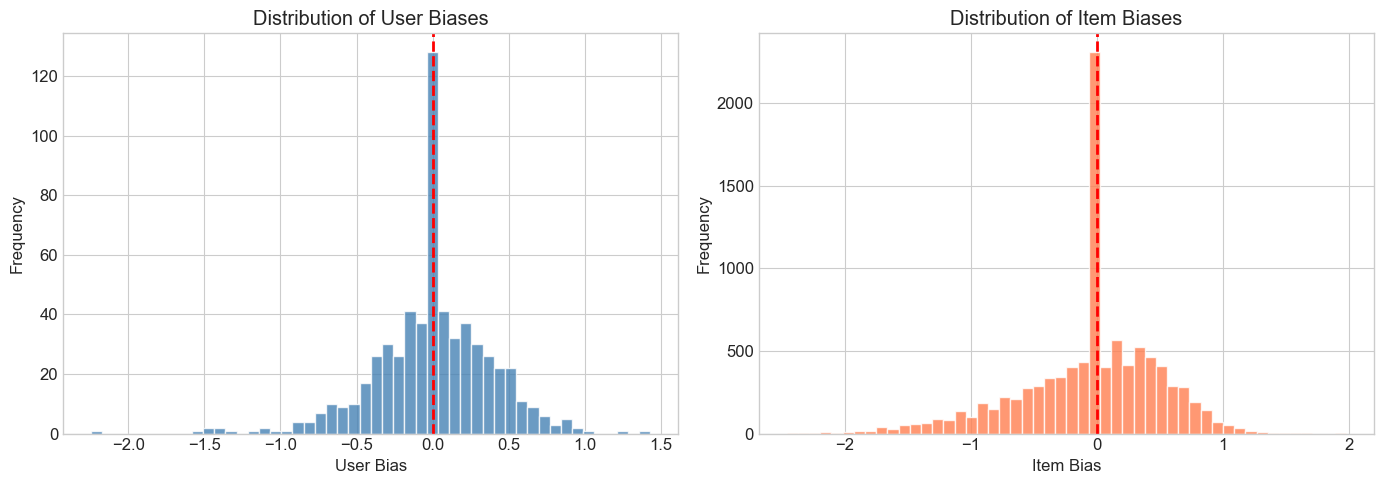

User bias range:  [-2.244, 1.431]
Item bias range:  [-2.458, 1.979]


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# User bias distribution
axes[0].hist(user_biases, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('User Bias')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of User Biases')

# Item bias distribution  
axes[1].hist(item_biases, bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Item Bias')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Item Biases')

plt.tight_layout()
plt.savefig('../figures/practical_2_biases.pdf', dpi=150, bbox_inches='tight', format='pdf')
plt.show()

print(f"User bias range:  [{user_biases.min():.3f}, {user_biases.max():.3f}]")
print(f"Item bias range:  [{item_biases.min():.3f}, {item_biases.max():.3f}]")

## 7. Top Rated Items (by Item Bias)

In [17]:
# Get top items by positive bias
top_item_indices = np.argsort(item_biases)[::-1][:15]

# Map back to original movie IDs
idx_to_movieid = {v: k for k, v in dataset._item_id_map.items()}

print("Top 15 Items by Positive Bias (Most Loved Movies):")
print("=" * 60)
for rank, idx in enumerate(top_item_indices, 1):
    movie_id = idx_to_movieid.get(idx, -1)
    title = dataset.get_movie_title(movie_id)
    bias = item_biases[idx]
    print(f"{rank:2d}. [{bias:+.3f}] {title}")

Top 15 Items by Positive Bias (Most Loved Movies):
Loading movies from ..\data\ml-latest-small\movies.csv...
Loaded 9,742 movies
 1. [+1.979] Doctor Who: The Time of the Doctor (2013)
 2. [+1.929] Alien Contamination (1980)
 3. [+1.929] Galaxy of Terror (Quest) (1981)
 4. [+1.929] Troll 2 (1990)
 5. [+1.635] Submarine (2010)
 6. [+1.596] Looker (1981)
 7. [+1.596] Master of the Flying Guillotine (Du bi quan wang da po xue di zi) (1975)
 8. [+1.493] Bossa Nova (2000)
 9. [+1.367] Day of the Doctor, The (2013)
10. [+1.352] Holy Mountain, The (Montaña sagrada, La) (1973)
11. [+1.352] Unfaithfully Yours (1948)
12. [+1.345] Bad Boy Bubby (1993)
13. [+1.344] Act of Killing, The (2012)
14. [+1.344] Umberto D. (1952)
15. [+1.344] Who Killed Chea Vichea? (2010)


In [18]:
# Get bottom items by negative bias
bottom_item_indices = np.argsort(item_biases)[:15]

print("Bottom 15 Items by Negative Bias (Least Loved Movies):")
print("=" * 60)
for rank, idx in enumerate(bottom_item_indices, 1):
    movie_id = idx_to_movieid.get(idx, -1)
    title = dataset.get_movie_title(movie_id)
    bias = item_biases[idx]
    print(f"{rank:2d}. [{bias:+.3f}] {title}")

Bottom 15 Items by Negative Bias (Least Loved Movies):
 1. [-2.458] Jason X (2002)
 2. [-2.427] Baxter (1989)
 3. [-2.427] Dead of Night (1945)
 4. [-2.427] Don't Look Now (1973)
 5. [-2.427] Collector, The (1965)
 6. [-2.375] Pokemon 4 Ever (a.k.a. Pokémon 4: The Movie) (2002)
 7. [-2.284] Prom Night (2008)
 8. [-2.231] Pokémon Heroes (2003)
 9. [-2.202] Spice World (1997)
10. [-2.159] Book of Shadows: Blair Witch 2 (2000)
11. [-2.151] Follow Me, Boys! (1966)
12. [-2.151] Uncle Nino (2003)
13. [-2.150] Human Centipede, The (First Sequence) (2009)
14. [-2.141] Disaster Movie (2008)
15. [-2.117] Date Movie (2006)
